## Deep Neural Network (DNN) optimization for MNIST digit classification with Keras Tuner

In [ ]:
"""
# Project Title:
Optimized DNN with tensorflow and keras tuner for MNIST image classification

# Project objective:
Key objectives are:
•	Create a DNN model for digit classification   
•	Prepare the data for model training with normalization 
•	Apply Keras Tuner for hyperparameter tuning 
•	Network optimized with hidden layer size, dropout rate, and learning rate 
•	 Analyze model efficiency on test data  
•	Maximize model accuracy for digit classification

# Tools:
•	Python  | Jupyter Notebook | TensorFlow  , Keras |  Keras Tuner | Matplotlib

# Keys:
•	Use Keras Tuner for hyperparameter tuning
•	Analyze multiple combinations of optimization settings, model complexity, regularization)
•	Gain top results: high performance (val. accuracy =  98%, test accuracy = 98%
•	Created a repeatable model pipeline
•	Clearly shown basic understanding of DNN model design, model optimization and evaluation


"""

In [ ]:
# MNIST_Digit_Classification_DNN_Hyperparameter_Optimization_Keras Tuner

In [1]:
import tensorflow as tf

### Importing and preparing the MNIST dataset for model training

In [3]:
# Load the MNIST dataset

mnist_raw_dataset = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist_raw_dataset.load_data()

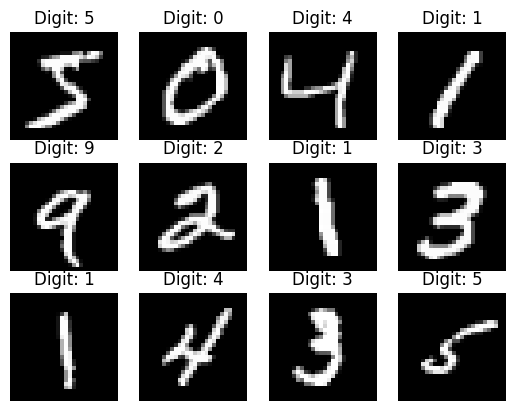

In [5]:
import matplotlib.pyplot as plt

for a in range(12):
    plt.subplot(3, 4, a + 1)
    plt.imshow(x_train[a], cmap = 'gray')
    plt.title(f'Digit: {y_train[a]}')
    plt.axis('off')

plt.show()

In [7]:
# Normalizing the pixel values of each MNIST image from 0-255 to 0-1.

x_train = x_train.reshape(-1, 784).astype('float32') / 255.0
print(x_train.shape )
print(f'Train sample size: {x_train.shape[0]}')

print()

x_test = x_test.reshape(-1, 784).astype('float32') / 255.0
print(x_test.shape )
print(f'Test sample size: {x_test.shape[0]}')


(60000, 784)
Train sample size: 60000

(10000, 784)
Test sample size: 10000


### Define Keras neural network model with hyperparameter search

In [9]:
from tensorflow import keras
from tensorflow.keras import layers

def create_keras_neural_network_model(tune_hyperparameter):
    model = keras.Sequential()

    # Define number of neurons
    tune_hyperparameter_num_neurons = tune_hyperparameter.Int('num_neurons', min_value=64, max_value=256, step=64) 
    model.add(layers.Dense(tune_hyperparameter_num_neurons, activation = 'relu', input_shape=(784,)))  #  1 hidden layer only

    
    # Select dropout rate
    tuned_dropout_rate = tune_hyperparameter.Float('dropout_rate', 0.1, 0.4, step = 0.1)      #  Choose one value at one trial
    model.add(layers.Dropout(tuned_dropout_rate))

    
    model.add(layers.Dense(10, activation = 'softmax'))                                                       # Add softmax output layer
    tuned_learning_rate = tune_hyperparameter.Choice('optimizer_learning_rate', values=[0.01, 0.001, 0.0001])  # Take 1 learning rate at 1 trial

    model.compile(optimizer=keras.optimizers.Adam(learning_rate = tuned_learning_rate),
                  loss = 'sparse_categorical_crossentropy',
                  metrics = ['accuracy']
                 )
    return model


####  Delete old hyperparameter tune results

In [11]:
import shutil

hyperparameter_tuning_directory_path = 'mnist_hyperparam_results'
shutil.rmtree(hyperparameter_tuning_directory_path, ignore_errors=True)

print(f'Deleted old hyperparameter tune results from: {hyperparameter_tuning_directory_path}')

Deleted old hyperparameter tune results from: mnist_hyperparam_results


### Random search trial outcomes with hyperparameter optimization from MNIST neural network

In [13]:
import keras_tuner as kt

# Set up keras tuner for random search
tuner = kt.RandomSearch(create_keras_neural_network_model,
                        objective = 'val_accuracy',
                        max_trials = 16,
                        executions_per_trial=1,
                        directory = 'mnist_hyperparam_results',
                        project_name = 'mnist_nn_hyperparam_tuning'
                       )

# Initiate the hyperparameter tuning
tuner.search(x_train, y_train,
             epochs = 6,            # For 1 trial
             validation_split = 0.2,  # 20% data for validation
             verbose = 1  
            )

Trial 16 Complete [00h 01m 45s]
val_accuracy: 0.9767500162124634

Best val_accuracy So Far: 0.9788333177566528
Total elapsed time: 00h 30m 34s


### Analyze best model on test data

In [16]:
best_tuned_model = tuner.get_best_models(num_models=1)[0]

loss_on_test_dataset, accuracy_on_test_dataset = best_tuned_model.evaluate(x_test, y_test, verbose=1)

print(f'loss on test dataset: {loss_on_test_dataset:.3f}')

print(f'accuracy on test dataset: {accuracy_on_test_dataset:.3f}')


313/313 [==============================] - 3s 6ms/step - loss: 0.0706 - accuracy: 0.9787
loss on test dataset: 0.071
accuracy on test dataset: 0.979


In [20]:
best_tuned_model.save('best_tuned_model.h5')

C:\Users\gobin\anaconda3\envs\tf_env\Lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


### Best Model Hyperparameters

In [22]:
best_hyperparam_set = tuner.get_best_hyperparameters(num_trials=1)[0]

print('Best Model Hyperparameters received:')
print(f" --Number of neurons in dense layer: {best_hyperparam_set.get('num_neurons')}")
print(f" --Fraction of neurons dropped in hidden layer: {best_hyperparam_set.get('dropout_rate')}")
print(f" --Learning rate used by optimizer: {best_hyperparam_set.get('optimizer_learning_rate')}")

Best Model Hyperparameters received:
 --Number of neurons in dense layer: 192
 --Fraction of neurons dropped in hidden layer: 0.1
 --Learning rate used by optimizer: 0.001
